# exp-nb-profile-blend-faithful-01

## 목적
faithful H0(구조화 LR 0.80 + 자동 specialist LGBM 0.20)를 변경하지 않고, train-only `gene × functional event type` Complement NB 확률을 고정 비율로 보완한다.

- 비교: H0 / Complement NB 단독 / `0.75 × H0 + 0.25 × NB`
- 검증: Stratified 5-fold, seeds `42 / 777 / 2024`
- 채택: 세 seed 모두 H0보다 상승, 평균 delta ≥ 0.005, 양의 fold ≥ 11/15

## 규칙 계약
- OOF에서는 `train.csv`만 읽고 `test.csv`는 읽지 않는다.
- profile vocabulary·NB fit은 outer-fold train에서만 생성한다. validation에는 transform만 적용한다.
- 고정 암종명·유전자·exact mutation 목록을 사용하지 않는다.
- WT, 빈 문자열, NaN은 mutation event를 만들지 않는다.
- H0는 `exp_model_006`의 GS 내부 faithful 구현만 재사용하며, 다른 팀원 코드에는 의존하지 않는다.


In [8]:
from pathlib import Path
import json
import subprocess
import sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
BASE = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_007'
RUNNER = BASE / 'common' / 'run_nb_profile_blend_3seed.py'
RESULT = BASE / 'result'
RUN_ID = 'exp-nb-profile-blend-faithful-01'
SEEDS = (42, 777, 2024)
RUN_EXPERIMENT = True
assert RUNNER.exists()
assert (ROOT / 'data' / 'raw' / 'train.csv').exists()
{'runner': RUNNER, 'result_dir': RESULT, 'seeds': SEEDS}


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_007/common/run_nb_profile_blend_3seed.py'),
 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_007/result'),
 'seeds': (42, 777, 2024)}

In [2]:
# 빠른 계약 검증: 전체 CV는 실행하지 않습니다.
smoke = subprocess.run([sys.executable, str(RUNNER), '--smoke'], text=True, capture_output=True)
print(smoke.stdout)
if smoke.returncode:
    raise RuntimeError(smoke.stderr)


{"smoke": "ok", "test_read": false, "nan_as_mutation_count": 0, "fixed_class_gene_mutation_rules": false}



In [3]:
# 전체 3-seed 실행: fold별로 메모리를 해제하며 tqdm로 로그를 표시합니다.
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--run-id', RUN_ID, '--seeds', *map(str, SEEDS)]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='H0 + NB profile 3-seed', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 저장된 결과만 읽습니다.')


H0 + NB profile 3-seed: 1line [00:05,  5.03s/line]

[NB-profile] seed 42, fold 1/5


H0 + NB profile 3-seed: 2line [03:04, 107.52s/line]

[NB-profile] seed 42, fold 2/5


H0 + NB profile 3-seed: 3line [06:11, 143.84s/line]

...

H0 + NB profile 3-seed: 15line [45:17, 193.57s/line]

[NB-profile] seed 2024, fold 5/5


H0 + NB profile 3-seed: 16line [48:53, 200.43s/line]

{"seeds": [42, 777, 2024], "weights": {"h0": 0.75, "complement_nb": 0.25}, "all_seed_delta_positive": false, "mean_delta": -0.00043629470428419026, "positive_fold_count": 5, "h0_seed42_reference_delta": -1.4001810832997563e-07, "h0_seed42_reference_match": true, "leakage_check": true, "nan_as_mutation_count": 0, "test_read": false, "decision": "rejected_or_not_detected"}


H0 + NB profile 3-seed: 16line [48:54, 183.39s/line]


In [7]:
available = sorted(RESULT.glob("*.csv"))
print("RESULT:", RESULT)
print("CSV files:")
for path in available:
    print("-", path.name)

RESULT: /Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_007/result
CSV files:


In [9]:
import matplotlib.pyplot as plt
import pandas as pd

seed_summary = pd.read_csv(RESULT / f'{RUN_ID}_seed_summary.csv')
three_seed = pd.read_csv(RESULT / f'{RUN_ID}_3seed_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_fold_metrics.csv')
class_metrics = pd.read_csv(RESULT / f'{RUN_ID}_class_metrics.csv')
audit = json.loads((RESULT / f'{RUN_ID}_leakage_audit.json').read_text(encoding='utf-8'))

assert seed_summary.leakage_check.all()
assert seed_summary.nan_as_mutation_count.eq(0).all()
assert audit['test_read'] is False
display(seed_summary.sort_values(['seed', 'variant']))
display(three_seed.sort_values('oof_macro_f1_mean', ascending=False))
audit


,seed,variant,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0
1,42,ComplementNB_profile,0.205163,0.251734,13968.4,0,True,0,968.517238,-0.339580
0,42,H0,0.544744,0.555556,8193.2,0,True,0,968.492909,0.000000
2,42,H0_075_ComplementNB_025,0.541125,0.553459,13968.4,0,True,0,968.542293,-0.003618
4,777,ComplementNB_profile,0.205890,0.252701,13970.0,0,True,0,966.368919,-0.332820
3,777,H0,0.538710,0.551685,8188.4,0,True,0,966.344938,0.000000
5,777,H0_075_ComplementNB_025,0.537013,0.549589,13970.0,0,True,0,966.393169,-0.001697
7,2024,ComplementNB_profile,0.209492,0.256894,13972.4,0,True,0,993.403240,-0.334814
6,2024,H0,0.544306,0.556201,8193.0,0,True,0,993.378959,0.000000
8,2024,H0_075_ComplementNB_025,0.548313,0.557168,13972.4,0,True,0,993.427401,0.004007


,variant,seed_count,oof_macro_f1_mean,oof_macro_f1_std,delta_vs_h0_mean,delta_vs_h0_std,feature_count_mean,leakage_check,nan_as_mutation_count
1,H0,3,0.542587,0.003365,0.000000,0.000000,8191.533333,True,0
2,H0_075_ComplementNB_025,3,0.542150,0.005720,-0.000436,0.003966,13970.266667,True,0
0,ComplementNB_profile,3,0.206849,0.002318,-0.335738,0.003474,13970.266667,True,0


{'seeds': [42, 777, 2024],
 'weights': {'h0': 0.75, 'complement_nb': 0.25},
 'all_seed_delta_positive': False,
 'mean_delta': -0.00043629470428419026,
 'positive_fold_count': 5,
 'h0_seed42_reference_delta': -1.4001810832997563e-07,
 'h0_seed42_reference_match': True,
 'leakage_check': True,
 'nan_as_mutation_count': 0,
 'test_read': False,
 'decision': 'rejected_or_not_detected'}

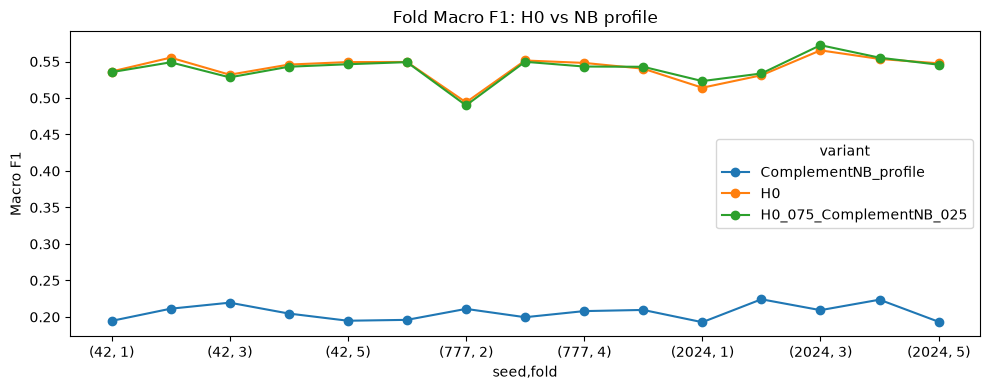

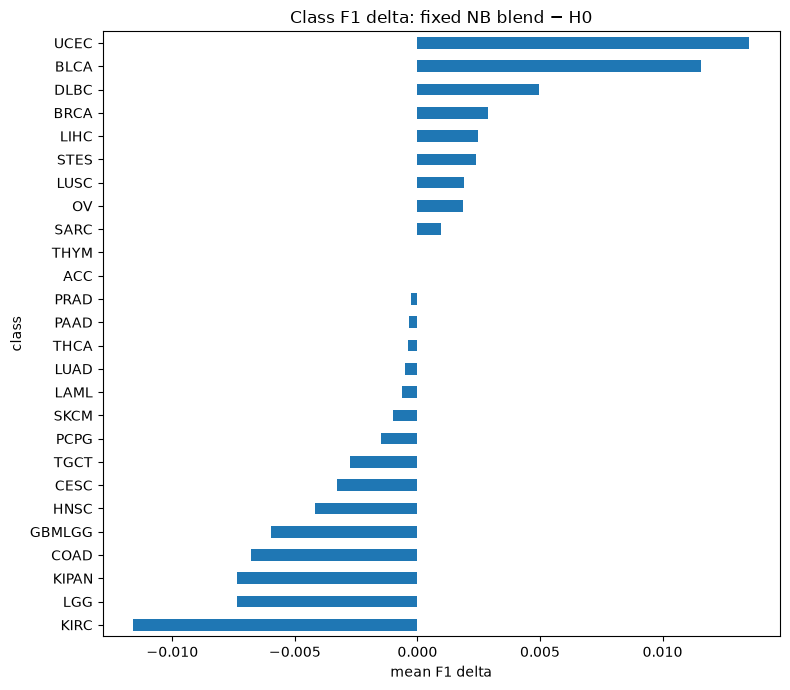

In [10]:
fold_view = folds.pivot_table(index=['seed', 'fold'], columns='variant', values='macro_f1')
ax = fold_view.plot(marker='o', figsize=(10, 4), title='Fold Macro F1: H0 vs NB profile')
ax.set_ylabel('Macro F1')
plt.tight_layout()
plt.show()

f1_view = class_metrics.pivot_table(index=['seed', 'class'], columns='variant', values='f1')
f1_delta = (f1_view['H0_075_ComplementNB_025'] - f1_view['H0']).groupby('class').mean().sort_values()
ax = f1_delta.plot.barh(figsize=(8, 7), title='Class F1 delta: fixed NB blend − H0')
ax.set_xlabel('mean F1 delta')
plt.tight_layout()
plt.show()


In [11]:
decision = audit['decision']
positive_folds = audit['positive_fold_count']
mean_delta = audit['mean_delta']
print(f'자동 판정: {decision}')
print(f'평균 delta: {mean_delta:+.6f}, 양의 fold: {positive_folds}/15')
print('채택 조건: H0 재현, 세 seed 모두 양수, 평균 +0.005 이상, 양의 fold 11/15 이상')


자동 판정: rejected_or_not_detected
평균 delta: -0.000436, 양의 fold: 5/15
채택 조건: H0 재현, 세 seed 모두 양수, 평균 +0.005 이상, 양의 fold 11/15 이상
